In [1]:
import json
import pandas as pd

with open("../data/raw/restaurantes_raw.json", encoding="utf-8") as f:
    raw = json.load(f)

elementos = raw["data"]["elements"]
print(f"Total elementos cargados: {len(elementos)}")

Total elementos cargados: 2026


In [2]:
registros = []

for el in elementos:
    tags = el.get("tags", {})
    registros.append({
        "osm_id":      el.get("id"),
        "tipo_osm":    el.get("type"),          
        "amenity":     tags.get("amenity"),
        "nombre":      tags.get("name"),
        "cocina":      tags.get("cuisine"),
        "ciudad":      tags.get("addr:city"),
        "calle":       tags.get("addr:street"),
        "cp":          tags.get("addr:postcode"),
        "telefono":    tags.get("phone"),
        "web":         tags.get("website"),
        "horario":     tags.get("opening_hours"),
        "lat":         el.get("lat"),
        "lon":         el.get("lon"),
    })

df = pd.DataFrame(registros)
print(df.shape)
df.head()

(2026, 13)


,osm_id,tipo_osm,amenity,nombre,cocina,ciudad,calle,cp,telefono,web,horario,lat,lon
0,255174168,node,bar,Casa Antidio,NaN,Gijón/Xixón,NaN,NaN,NaN,NaN,NaN,43.539424,-5.683328
1,255174169,node,bar,Cervecería Juar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.539845,-5.683449
2,290225166,node,bar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.546543,-5.878637
3,480729340,node,bar,Triskel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.417795,-4.754557
4,480729342,node,bar,Dorado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.418465,-4.754313


In [3]:
nulos = df.isnull().sum().sort_values(ascending=False)
pct   = (nulos / len(df) * 100).round(1)
pd.DataFrame({"nulos": nulos, "%": pct})

,nulos,%
web,1982,97.8
horario,1952,96.3
telefono,1902,93.9
cocina,1843,91.0
cp,1827,90.2
calle,1714,84.6
ciudad,1652,81.5
nombre,671,33.1
amenity,575,28.4
lat,91,4.5


In [4]:
# Elimina filas sin nombre (no nos sirven de nada)
df = df.dropna(subset=["nombre"])

# Normaliza texto: minúsculas y sin espacios extra
for col in ["nombre", "ciudad", "cocina", "amenity"]:
    df[col] = df[col].str.strip().str.lower()

# Elimina duplicados por osm_id
df = df.drop_duplicates(subset="osm_id")

print(f"Registros tras limpieza: {len(df)}")
df.head()

Registros tras limpieza: 1355


,osm_id,tipo_osm,amenity,nombre,cocina,ciudad,calle,cp,telefono,web,horario,lat,lon
0,255174168,node,bar,casa antidio,NaN,gijón/xixón,NaN,NaN,NaN,NaN,NaN,43.539424,-5.683328
1,255174169,node,bar,cervecería juar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.539845,-5.683449
3,480729340,node,bar,triskel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.417795,-4.754557
4,480729342,node,bar,dorado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.418465,-4.754313
5,481013818,node,bar,madison,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.417770,-4.753516


In [5]:
df.to_json("../data/processed/restaurantes_clean.json",
           orient="records", force_ascii=False, indent=2)

df.to_csv("../data/processed/restaurantes_clean.csv",
          index=False, encoding="utf-8")

print("Guardado en data/processed/")

Guardado en data/processed/


<Axes: title={'center': 'Locales por tipo en Asturias'}, xlabel='Tipo', ylabel='Cantidad'>

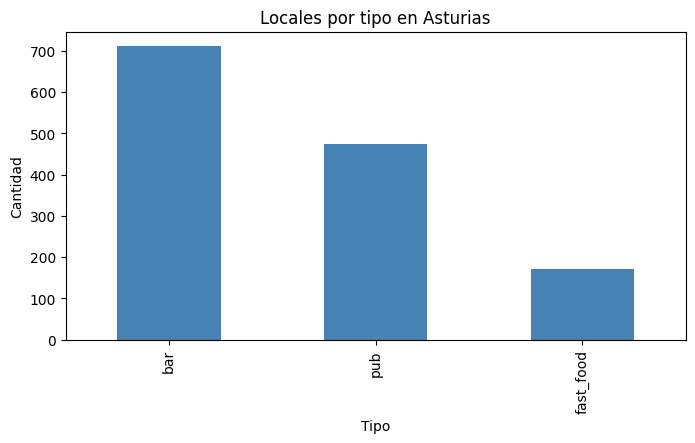

In [6]:
import subprocess
subprocess.run(["pip", "install", "matplotlib"])

df["amenity"].value_counts().plot(
    kind="bar", 
    title="Locales por tipo en Asturias",
    xlabel="Tipo",
    ylabel="Cantidad",
    color="steelblue",
    figsize=(8, 4)
)

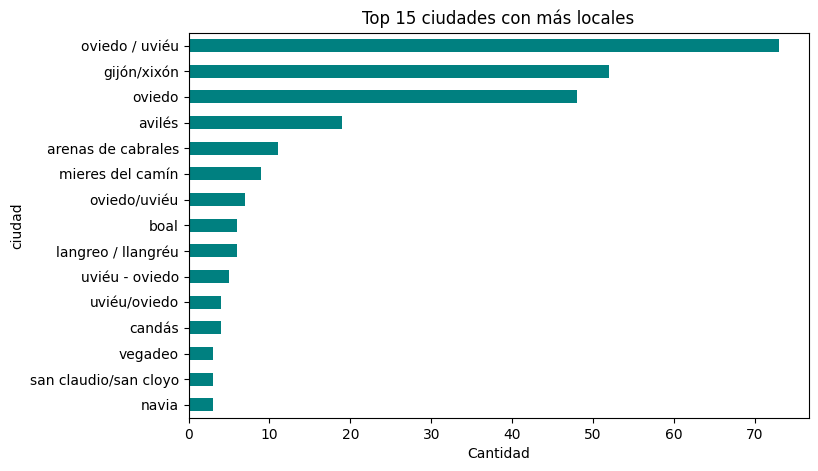

In [7]:
df["ciudad"].value_counts().head(15).plot(
    kind="barh",
    title="Top 15 ciudades con más locales",
    xlabel="Cantidad",
    figsize=(8, 5),
    color="teal"
).invert_yaxis()

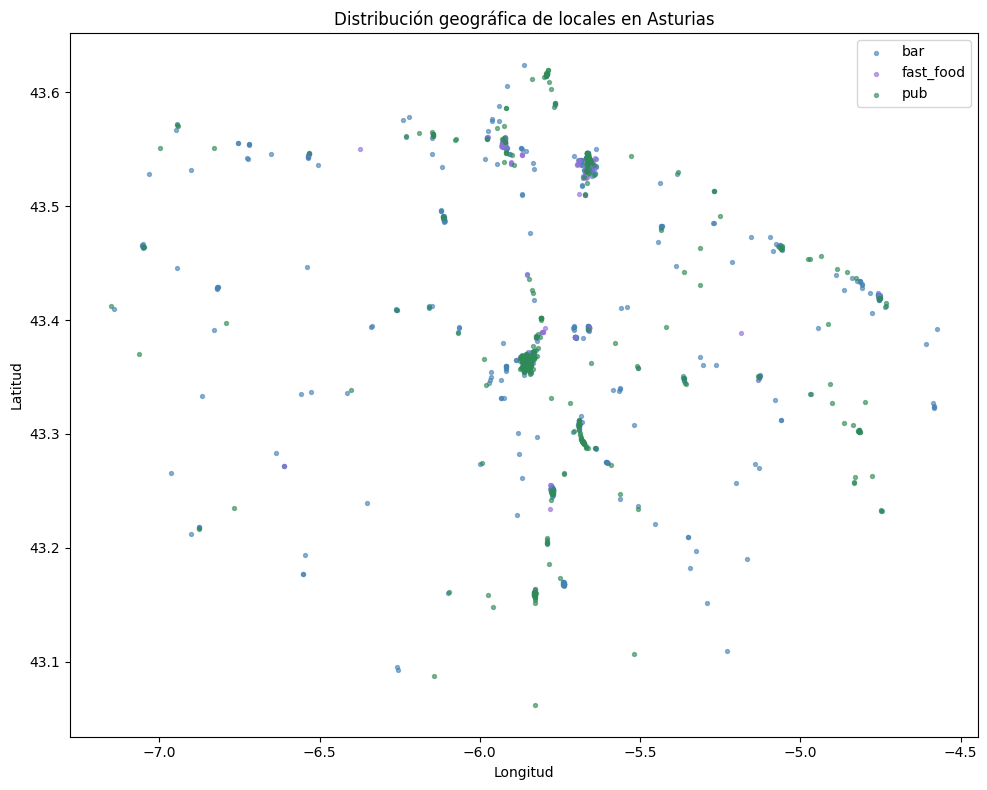

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

colores = {
    "restaurant": "tomato",
    "bar":        "steelblue",
    "cafe":       "goldenrod",
    "fast_food":  "mediumpurple",
    "pub":        "seagreen",
}

for amenity, grupo in df.groupby("amenity"):
    ax.scatter(
        grupo["lon"], grupo["lat"],
        c=colores.get(amenity, "gray"),
        label=amenity,
        s=8,
        alpha=0.6
    )

ax.set_title("Distribución geográfica de locales en Asturias")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
df["cocina"].value_counts()

cocina
burger                                                               53
pizza                                                                30
kebab                                                                21
regional                                                             18
chicken                                                              11
sandwich                                                              9
churro                                                                4
spanish                                                               3
local                                                                 2
tex-mex                                                               2
coffee_shop                                                           1
hot_dog;burger;coffee_shop;ice_cream;breakfast                        1
burger;international;breakfast;tea;coffee_shop;pizza                  1
buschenschank;spanish;coffee_shop;barbecue;fish;seafood;b

In [10]:
registros_v2 = []

for el in elementos:
    tags = el.get("tags", {})
    registros_v2.append({
        "osm_id":     el.get("id"),
        "nombre":     tags.get("name"),
        "amenity":    tags.get("amenity"),
        "cocina":     tags.get("cuisine"),
        "ciudad":     tags.get("addr:city"),
        "diet_vegan": tags.get("diet:vegan"),
        "diet_veg":   tags.get("diet:vegetarian"),
        "lat":        el.get("lat"),
        "lon":        el.get("lon"),
    })

df2 = pd.DataFrame(registros_v2)
print(df2["diet_vegan"].value_counts())

diet_vegan
yes    4
no     3
Name: count, dtype: int64


Locales con opción vegana: 4


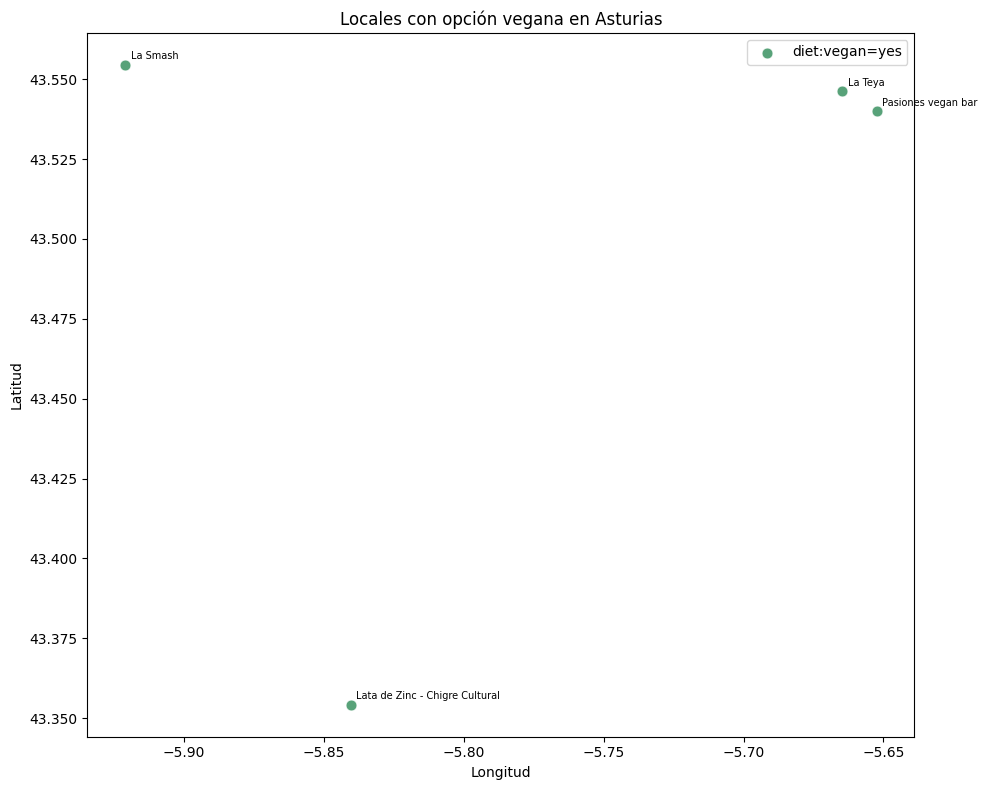

In [11]:
import matplotlib.pyplot as plt

veganos = df2[df2["diet_vegan"].isin(["yes", "only"])].dropna(subset=["lat", "lon"])
print(f"Locales con opción vegana: {len(veganos)}")

fig, ax = plt.subplots(figsize=(10, 8))

colores = {"yes": "seagreen", "only": "limegreen"}
for valor, grupo in veganos.groupby("diet_vegan"):
    ax.scatter(
        grupo["lon"], grupo["lat"],
        c=colores.get(valor, "gray"),
        label=f"diet:vegan={valor}",
        s=60,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5
    )

for _, row in veganos.iterrows():
    if pd.notna(row["nombre"]):
        ax.annotate(
            row["nombre"],
            (row["lon"], row["lat"]),
            fontsize=7,
            xytext=(4, 4),
            textcoords="offset points"
        )

ax.set_title("Locales con opción vegana en Asturias")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Diccionario de equivalencias (variantes -> nombre normalizado)
normalizar_ciudades = {
    "oviedo / uvieu":   "oviedo",
    "oviedo/uvieu":     "oviedo",
    "oviedo / uviéu":   "oviedo",
    "oviedo/uviéu":     "oviedo",
    "uviéu/oviedo":     "oviedo",
    "uvieu/oviedo":     "oviedo",
    "oviedo/uviéu":     "oviedo",
    "uviéu - oviedo":    "oviedo",
    "uvieu":            "oviedo",
    "uviéu":            "oviedo",
    "gijón/xixón":      "gijón",
    "gijon/xixon":      "gijón",
    "gijón / xixón":    "gijón",
    "gijon":            "gijón",
    "xixón":            "gijón",
    "xixon":            "gijón",
    "avilés/avilés":    "avilés",
    "aviles":           "avilés",
    "mieres del camín": "mieres",
    "mieres del camin": "mieres",
    "langreo / llangréu": "langreo",
    "langreo/llangréu": "langreo",
    "llangréu":         "langreo",
    "llanes/llanes":    "llanes",
    "cangas de onís":   "cangas de onís",
    "cangas de onis":   "cangas de onís",
}

df["ciudad"] = (
    df["ciudad"]
    .str.strip()
    .str.lower()
    .replace(normalizar_ciudades)
)

df.to_json('../data/processed/restaurantes_clean.json', orient='records', force_ascii=False, indent=2)
print('Guardado. Top ciudades:')
print(df['ciudad'].value_counts().head(10))


Guardado. Top ciudades:
ciudad
oviedo                   138
gijón                     52
avilés                    19
arenas de cabrales        11
mieres                     9
langreo                    7
boal                       6
candás                     4
vegadeo                    3
san claudio/san cloyo      3
Name: count, dtype: int64


In [13]:
import requests

url = "https://servicios.ine.es/wstempus/js/ES/OPERACIONES_DISPONIBLES"
r = requests.get(url, timeout=30, headers={"User-Agent": "GastroAstur/1.0"})
data = r.json()

# Busca operaciones relacionadas con padrón municipal
for op in data:
    nombre = op.get("Nombre", "")
    if "padrón" in nombre.lower() or "padron" in nombre.lower() or "población" in nombre.lower():
        print(op.get("Id"), "|", nombre)

21 | Estimaciones de la Población Actual (ePOBa)
22 | Cifras Oficiales de Población de los Municipios Españoles: Revisión del Padrón Municipal
36 | Poblaciones de derecho desde 1986 hasta 1995. Cifras oficiales sacadas del Padrón.
52 | Proyecciones de Población a Corto Plazo
54 | Proyecciones de Población a Largo Plazo
72 | Cifras de Población
205 | Flujos de la Población Activa
230 | Estadística del Padrón de la Población Española Residente en el Extranjero
293 | Encuesta de Población Activa (EPA)
450 | Estadística Continua de Población


In [14]:
import json
import pandas as pd

# Carga el JSON
with open("../data/raw/poblacion_asturias.json", encoding="utf-8") as f:
    raw_pob = json.load(f)

# Convierte a DataFrame filtrando solo filas Total
df_pob = pd.DataFrame(raw_pob)

# Limpia el nombre del concejo
df_pob["concejo"] = (
    df_pob["nombre"]
    .str.replace(r"\. Total\. Total habitantes\. Personas\..*", "", regex=True)
    .str.strip()
    .str.lower()
)

# Elimina la fila de Asturias total y queda solo municipios
df_pob = df_pob[df_pob["concejo"] != "asturias"].reset_index(drop=True)

# Renombra y selecciona columnas útiles
df_pob = df_pob[["concejo", "poblacion", "anio"]].copy()
df_pob["poblacion"] = df_pob["poblacion"].astype(int)

print(f"Municipios: {len(df_pob)}")
print(df_pob.head(10))

Municipios: 78
               concejo  poblacion  anio
0              allande       1506  2025
1                aller      10011  2025
2               amieva        591  2025
3               avilés      75517  2025
4  belmonte de miranda       1366  2025
5              bimenes       1639  2025
6                 boal       1372  2025
7             cabrales       1884  2025
8             cabranes       1094  2025
9              candamo       1902  2025


In [15]:
# Cuenta locales por concejo
locales_por_concejo = (
    df.groupby("ciudad")
    .size()
    .reset_index(name="num_locales")
    .rename(columns={"ciudad": "concejo"})
)

# Une con población
df_cruce = pd.merge(locales_por_concejo, df_pob, on="concejo", how="inner")

# Calcula ratio
df_cruce["locales_por_1000hab"] = (
    df_cruce["num_locales"] / df_cruce["poblacion"] * 1000
).round(2)

# Ordena por ratio
df_cruce = df_cruce.sort_values("locales_por_1000hab", ascending=False)

print(df_cruce.head(15))

               concejo  num_locales  poblacion  anio  locales_por_1000hab
1                 boal            6       1372  2025                 4.37
14             vegadeo            3       3928  2025                 0.76
12              oviedo          138     223968  2025                 0.62
13  tapia de casariego            2       3538  2025                 0.57
11               navia            3       8031  2025                 0.37
5              colunga            1       3143  2025                 0.32
4            castropol            1       3202  2025                 0.31
0               avilés           19      75517  2025                 0.25
9               mieres            9      36373  2025                 0.25
10                nava            1       5244  2025                 0.19
6                gijón           52     269894  2025                 0.19
7              langreo            7      38612  2025                 0.18
8               llanes            2   

In [16]:
df_cruce.to_json("../data/processed/locales_por_habitante.json",
                 orient="records", force_ascii=False, indent=2)

df_cruce.to_csv("../data/processed/locales_por_habitante.csv",
                index=False, encoding="utf-8")

print("Guardado en data/processed/")

Guardado en data/processed/
